# Baseline: Dynamo (real) vs synthetic rollouts

Все вычисления и графики **в этом ноутбуке** (без отдельного CLI `analyze-baseline`).

**Что сравнивается**
- **Реальная трасса (Dynamo):** один путь функции из `<id>.compressed_trace.json` (как в `metrics-compare --reference-compressed`).
- **Сгенерированные:** каждая строка `rollouts_random/intra_traces.jsonl`.

**Метрики:** `block_visit_kl`, `edge_transition_kl` — чем **меньше**, тем ближе к референсу; `hot_path_ngram_overlap` — чем **больше** (до 1), тем лучше. Вертикальная линия **«Dynamo vs Dynamo»** — эталон «идеально совпало с собой» (KL ≈ 0, overlap ≈ 1). Линия **«pooled synthetic»** — все эпизоды склеены в один кандидат, как в полном `metrics-compare` по JSONL.


In [1]:
%matplotlib inline
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

REPO = Path("..").resolve()
CTUNING_DIR = REPO / "output" / "ctuning_shared-matmul-c"
SHOW_RUNS_JSONL_LENGTHS = True  # also plot env step counts from runs.jsonl if True


In [2]:
def ctuning_id_from_directory(ctuning_dir: Path) -> str:
    name = ctuning_dir.name
    if not name.startswith("ctuning_"):
        raise ValueError(f"Expected ctuning_<id>, got {name!r}")
    return name[len("ctuning_"):]


def detect_function_name(intra_jsonl: Path) -> str:
    for line in intra_jsonl.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        raw = json.loads(line)
        if isinstance(raw.get("function_name"), str):
            return str(raw["function_name"])
        seq = raw.get("sequence")
        if isinstance(seq, list) and seq and isinstance(seq[0], dict):
            return str(seq[0].get("func", "main"))
        return "main"
    raise ValueError(f"{intra_jsonl}: empty")


def intra_len_for_func(path: list, func: str) -> int:
    return sum(1 for f, _bb in path if f == func)


def load_runs_jsonl(runs_jsonl: Path) -> tuple[list[int], list[str]]:
    lengths, terms = [], []
    for line in runs_jsonl.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        raw = json.loads(line)
        lengths.append(int(raw.get("length", 0)))
        terms.append(str(raw.get("termination", "unknown")))
    return lengths, terms


In [3]:
ctuning_dir = CTUNING_DIR.resolve()
if not ctuning_dir.is_dir():
    raise FileNotFoundError(f"Set CTUNING_DIR. Missing: {ctuning_dir}")

cid = ctuning_id_from_directory(ctuning_dir)
compressed = ctuning_dir / f"{cid}.compressed_trace.json"
roll = ctuning_dir / "rollouts_random"
runs_jsonl = roll / "runs.jsonl"
intra_jsonl = roll / "intra_traces.jsonl"
summary_json = roll / "summary.json"

func = detect_function_name(intra_jsonl)
print("function:", func)
print("compressed:", compressed.is_file(), compressed)
print("intra_jsonl:", intra_jsonl.is_file(), intra_jsonl)


function: main
compressed: True /home/mitchell/dev/llvm/trace-synthesizer/output/ctuning_shared-matmul-c/shared-matmul-c.compressed_trace.json
intra_jsonl: True /home/mitchell/dev/llvm/trace-synthesizer/output/ctuning_shared-matmul-c/rollouts_random/intra_traces.jsonl


In [4]:
from trace_synthesizer.metrics.compare import run_metrics
from trace_synthesizer.metrics.loaders import (
    load_path_from_compressed_trace,
    load_paths_from_intra_traces_jsonl,
)
from trace_synthesizer.metrics.registry import DEFAULT_METRIC_ORDER
from trace_synthesizer.metrics.types import MetricContext

dynamo_path = load_path_from_compressed_trace(compressed, func)
synth_paths = load_paths_from_intra_traces_jsonl(intra_jsonl)
if not synth_paths:
    raise ValueError(f"No lines in {intra_jsonl}")
ctx = MetricContext(function_name=func)

dynamo_len = intra_len_for_func(dynamo_path, func)
synth_lens_intra = [intra_len_for_func(p, func) for p in synth_paths]
runs_lens, run_terms = load_runs_jsonl(runs_jsonl)

ref = [dynamo_path]
ref_self = {r.name: r.value for r in run_metrics(ref, ref, ctx)}
pooled_row = {r.name: r.value for r in run_metrics(ref, synth_paths, ctx)}
per_episode: list[dict] = []
for i, p in enumerate(synth_paths):
    row = {"episode": i}
    for r in run_metrics(ref, [p], ctx):
        row[r.name] = r.value
    per_episode.append(row)

print("episodes:", len(synth_paths), "Dynamo intra len:", dynamo_len)
print("ref_self (Dynamo vs Dynamo):", ref_self)
print("pooled (Dynamo vs all synth):", pooled_row)


episodes: 30 Dynamo intra len: 139122
ref_self (Dynamo vs Dynamo): {'block_visit_kl': 0.0, 'edge_transition_kl': 0.0, 'hot_path_ngram_overlap': 1.0}
pooled (Dynamo vs all synth): {'block_visit_kl': 0.2717356137269777, 'edge_transition_kl': 0.5501407454374394, 'hot_path_ngram_overlap': 1.0}


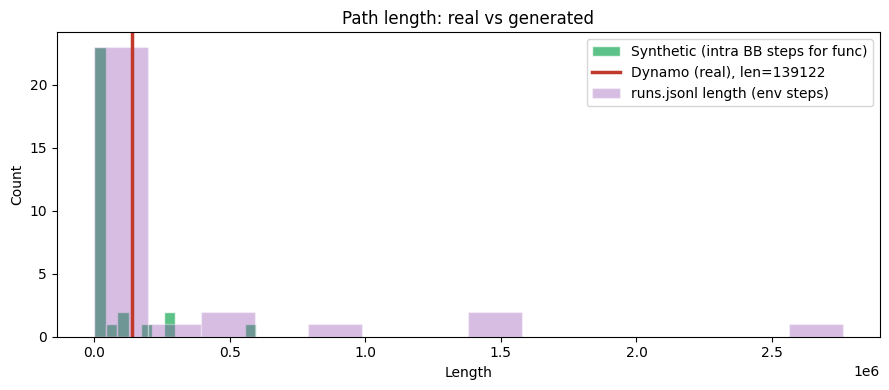

In [5]:
# Path lengths: synthetic distribution vs single real (Dynamo) length
fig, ax = plt.subplots(figsize=(9, 4))
if synth_lens_intra:
    ax.hist(synth_lens_intra, bins=min(40, max(8, len(set(synth_lens_intra)))), color="#27ae60", alpha=0.75, label="Synthetic (intra BB steps for func)", edgecolor="white")
ax.axvline(dynamo_len, color="#c0392b", lw=2.5, label=f"Dynamo (real), len={dynamo_len}")
if SHOW_RUNS_JSONL_LENGTHS and runs_lens:
    ax.hist(runs_lens, bins=min(40, max(8, len(set(runs_lens)))), color="#8e44ad", alpha=0.35, label="runs.jsonl length (env steps)", edgecolor="white")
ax.set_xlabel("Length")
ax.set_ylabel("Count")
ax.set_title("Path length: real vs generated")
ax.legend()
fig.tight_layout()
plt.show()


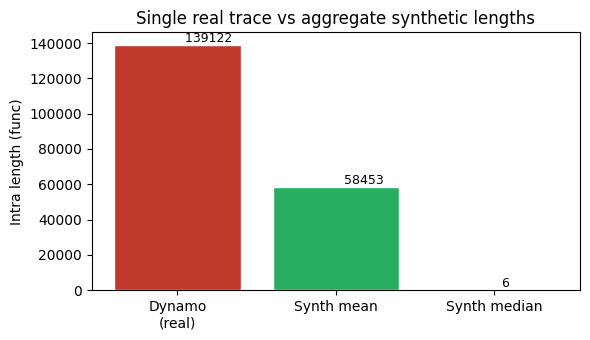

In [6]:
# Summary bars: real length vs synthetic mean/median
fig, ax = plt.subplots(figsize=(6, 3.5))
if synth_lens_intra:
    med = float(np.median(synth_lens_intra))
    mean = float(np.mean(synth_lens_intra))
else:
    med = mean = 0.0
labels = ["Dynamo\n(real)", "Synth mean", "Synth median"]
vals = [dynamo_len, mean, med]
colors = ["#c0392b", "#27ae60", "#2ecc71"]
ax.bar(labels, vals, color=colors, edgecolor="white")
ax.set_ylabel("Intra length (func)")
ax.set_title("Single real trace vs aggregate synthetic lengths")
for i, v in enumerate(vals):
    ax.text(i, v, f"  {v:.0f}", va="bottom", fontsize=9)
fig.tight_layout()
plt.show()


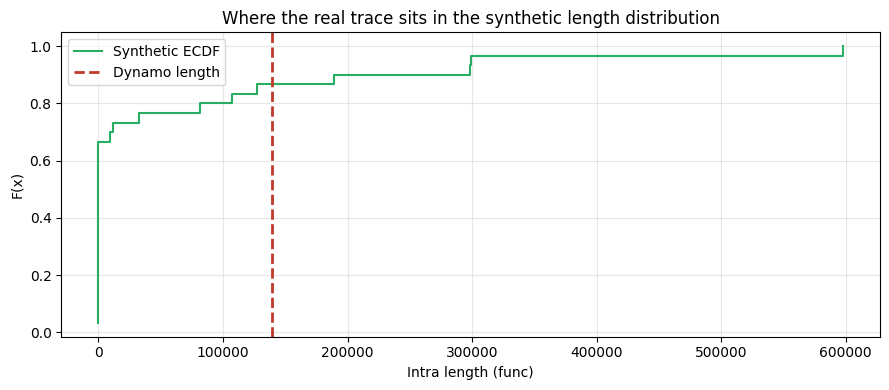

In [7]:
# ECDF of synthetic intra lengths + Dynamo on x-axis
fig, ax = plt.subplots(figsize=(9, 4))
xs = np.sort(np.array(synth_lens_intra, dtype=float))
if len(xs):
    y = np.arange(1, len(xs) + 1) / len(xs)
    ax.step(xs, y, where="post", color="#27ae60", label="Synthetic ECDF")
ax.axvline(dynamo_len, color="#c0392b", ls="--", lw=2, label="Dynamo length")
ax.set_xlabel("Intra length (func)")
ax.set_ylabel("F(x)")
ax.set_title("Where the real trace sits in the synthetic length distribution")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


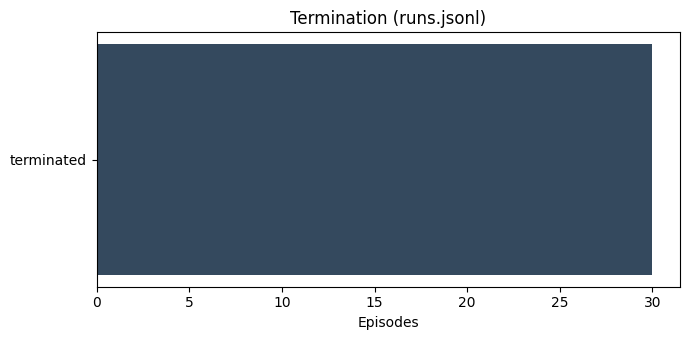

In [8]:
# Termination kinds (rollout env)
from collections import Counter
c = Counter(run_terms)
fig, ax = plt.subplots(figsize=(7, 3.5))
labs = list(c.keys())
vals = [c[k] for k in labs]
ax.barh(labs, vals, color="#34495e")
ax.set_xlabel("Episodes")
ax.set_title("Termination (runs.jsonl)")
fig.tight_layout()
plt.show()


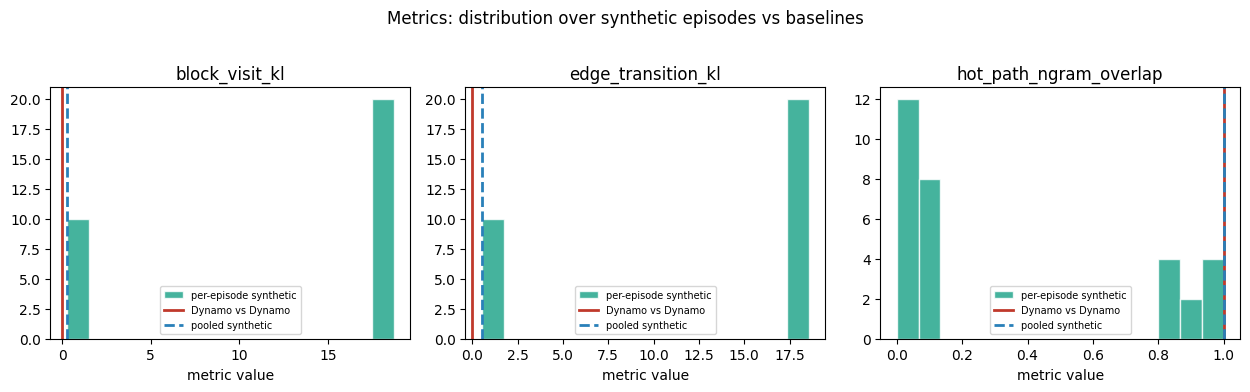

In [9]:
# Metrics: per-episode synthetic vs Dynamo + reference baselines
METRICS = [k for k in DEFAULT_METRIC_ORDER]
n_m = len(METRICS)
fig, axes = plt.subplots(1, n_m, figsize=(4.2 * n_m, 3.8))
if n_m == 1:
    axes = [axes]
for ax, mname in zip(axes, METRICS, strict=True):
    vals = [float(row[mname]) for row in per_episode if row.get(mname) is not None]
    if vals:
        ax.hist(vals, bins=min(25, max(6, len(vals) // 2)), color="#16a085", alpha=0.8, edgecolor="white", label="per-episode synthetic")
    rs = ref_self.get(mname)
    pl = pooled_row.get(mname)
    if rs is not None:
        ax.axvline(float(rs), color="#c0392b", lw=2, label="Dynamo vs Dynamo")
    if pl is not None:
        ax.axvline(float(pl), color="#2980b9", lw=2, ls="--", label="pooled synthetic")
    ax.set_title(mname)
    ax.set_xlabel("metric value")
    ax.legend(fontsize=7, loc="best")
fig.suptitle("Metrics: distribution over synthetic episodes vs baselines", y=1.02)
fig.tight_layout()
plt.show()


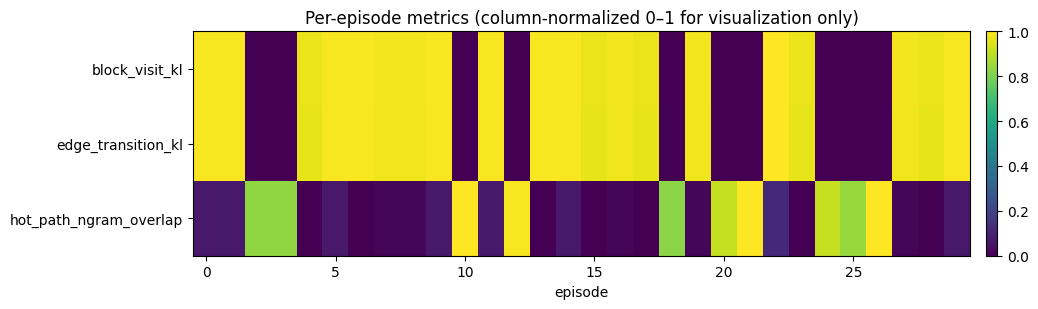

In [10]:
# Heatmap: normalized per-episode metrics (compare shapes across metrics)
M = np.array([[float(row[m]) if row.get(m) is not None else np.nan for m in METRICS] for row in per_episode], dtype=float)
if M.size and np.isfinite(M).any():
    col_min = np.nanmin(M, axis=0)
    col_max = np.nanmax(M, axis=0)
    span = np.where(col_max > col_min, col_max - col_min, 1.0)
    Z = (M - col_min) / span
    fig, ax = plt.subplots(figsize=(max(6, 0.35 * len(per_episode)), 3.2))
    im = ax.imshow(Z.T, aspect="auto", cmap="viridis", interpolation="nearest")
    ax.set_yticks(range(len(METRICS)), METRICS)
    ax.set_xlabel("episode")
    ax.set_title("Per-episode metrics (column-normalized 0–1 for visualization only)")
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    fig.tight_layout()
    plt.show()
else:
    print("skip heatmap: no metric matrix")


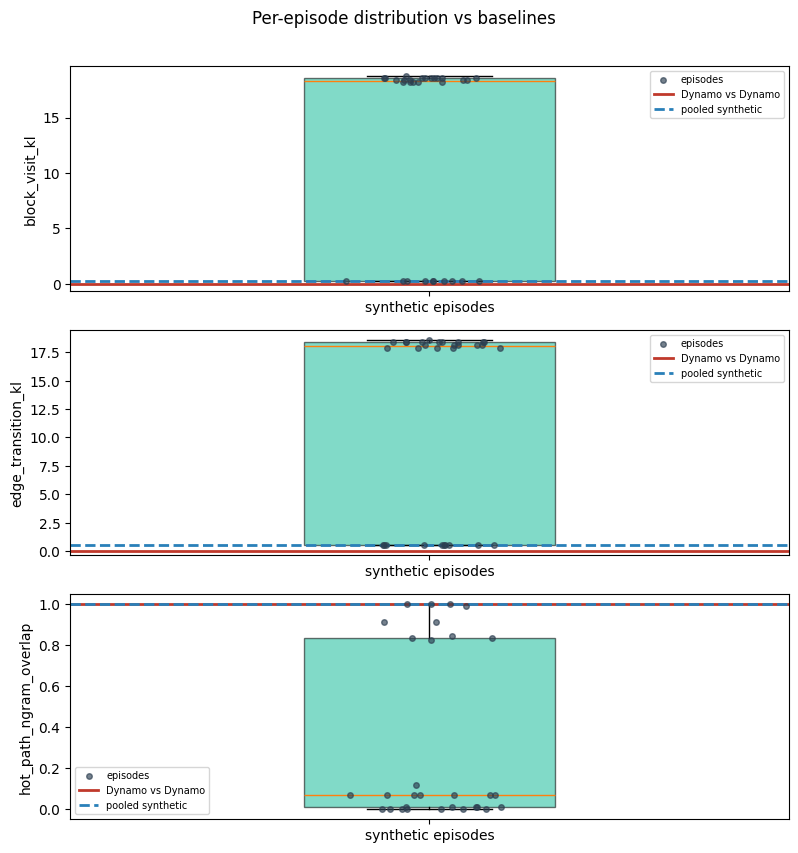

In [11]:
# Boxplot + jittered points: synthetic spread vs Dynamo baselines (horizontal lines)
rng = np.random.default_rng(0)
fig, axes = plt.subplots(n_m, 1, figsize=(8, 2.8 * n_m), sharex=False)
if n_m == 1:
    axes = [axes]
for ax, mname in zip(axes, METRICS, strict=True):
    vals = np.array([row.get(mname) for row in per_episode], dtype=float)
    mask = ~np.isnan(vals)
    if mask.any():
        ax.boxplot(vals[mask], positions=[1], widths=0.35, patch_artist=True,
                   boxprops=dict(facecolor="#1abc9c", alpha=0.55))
        jitter = rng.normal(0, 0.05, size=int(mask.sum()))
        ax.scatter(1 + jitter, vals[mask], s=16, c="#2c3e50", alpha=0.65, zorder=3, label="episodes")
    rs, pl = ref_self.get(mname), pooled_row.get(mname)
    if rs is not None:
        ax.axhline(float(rs), color="#c0392b", lw=2, label="Dynamo vs Dynamo")
    if pl is not None:
        ax.axhline(float(pl), color="#2980b9", lw=2, ls="--", label="pooled synthetic")
    ax.set_xticks([1])
    ax.set_xticklabels(["synthetic episodes"])
    ax.set_ylabel(mname)
    ax.legend(fontsize=7, loc="best")
fig.suptitle("Per-episode distribution vs baselines", y=1.01)
fig.tight_layout()
plt.show()


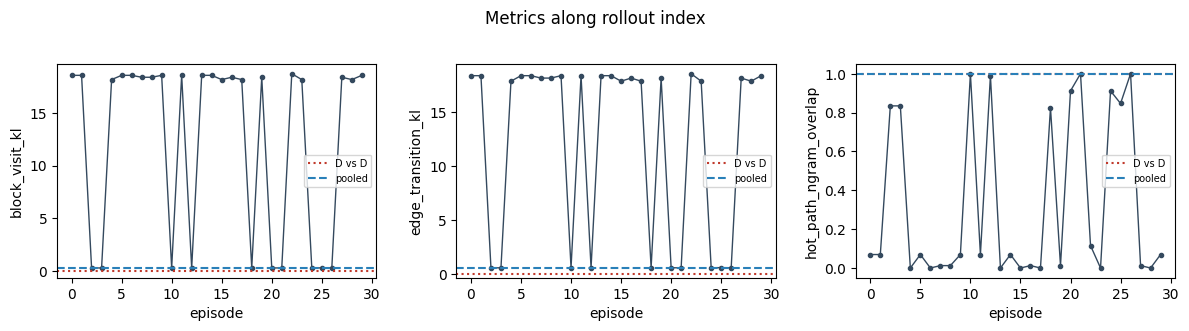

In [12]:
# Episode index vs each metric (how stable is the generator)
fig, axes = plt.subplots(1, n_m, figsize=(4 * n_m, 3.2))
if n_m == 1:
    axes = [axes]
for ax, mname in zip(axes, METRICS, strict=True):
    ys = [row.get(mname) for row in per_episode]
    xs = [row["episode"] for row in per_episode]
    ax.plot(xs, ys, "o-", ms=3, lw=1, color="#34495e")
    rs, pl = ref_self.get(mname), pooled_row.get(mname)
    if rs is not None:
        ax.axhline(float(rs), color="#c0392b", ls=":", label="D vs D")
    if pl is not None:
        ax.axhline(float(pl), color="#2980b9", ls="--", label="pooled")
    ax.set_xlabel("episode")
    ax.set_ylabel(mname)
    ax.legend(fontsize=7)
fig.suptitle("Metrics along rollout index", y=1.02)
fig.tight_layout()
plt.show()


In [13]:
from IPython.display import display

if pd is not None:
    df = pd.DataFrame([{k: v for k, v in r.items() if k != "episode"} for r in per_episode])
    display(df.describe().T)
else:
    print("Install pandas (poetry install --with dev) for describe() table")


,count,mean,std,min,25%,50%,75%,max
block_visit_kl,30.0,12.374539,8.704191,0.265846,0.276060,18.270522,18.564084,18.717970
edge_transition_kl,30.0,12.314617,8.462063,0.529543,0.555061,18.003772,18.370426,18.552483
hot_path_ngram_overlap,30.0,0.327194,0.426190,0.000000,0.012346,0.069360,0.834456,1.000000


### Как читать графики

- **Длины:** красная вертикаль — одна реальная трасса Dynamo; зелёная гистограмма — длины синтетических путей по тем же intra-событиям. Фиолетовая полупрозрачная гистограмма (если включено) — поле `length` из `runs.jsonl` (шаги среды); оно может отличаться от длины последовательности basic blocks.
- **KL:** линия «Dynamo vs Dynamo» около нуля; чем правее пики синтетики, тем сильнее расхождение распределений с референсом.
- **Overlap:** «Dynamo vs Dynamo» ≈ 1; чем ниже эпизоды, тем меньше пересечение hot n-грамм с реальной трассой.

Полный отчёт как JSON можно собрать из `ref_self`, `pooled_row`, `per_episode` в предыдущих ячейках.
